# **Animove**
### Spatial Dynamics, Temporal Rhythms, and Biological Influences on Bobcat (*Lynx rufus*) Movement Near Black Rock Forest, New York

**By**: Zhean Robby Ganituen, Jaztin Jacob Jimenez, Reece Benedict Orense, Ashley Paulianna Reyes, and Matthew Fraser Sim

---

# **1. Abstract**
This study investigates the spatial, temporal, and biological factors influencing the movement behaviors of Bobcats (*Lynx rufus*) near Black Rock Forest, New York. Utilizing high-frequency GPS telemetry data and biological metadata collected between 2020 and 2026, we explore individual activity budgets, circadian rhythms, and territorial boundaries. By applying spatial mapping techniques (KDE) and temporal feature engineering, this exploratory data analysis aims to uncover how intrinsic biological traits (such as sex, mass, and life-stage) correlate with the varied movement patterns of this elusive carnivore.

**Dataset**: LaPoint, S. 2026. Data from: Study “Carnivore movements near Black Rock Forest New York” [part]. Movebank Data Repository.

**Paper**: Oliver, R.Y. et al. 2026. Interacting effects of human presence and landscape modification on birds and mammals. Science. 392, 6800 (May 2026), 879–884. https://doi.org/10.1126/science.adq3396.

---

# **2. Dataset Description**

## **Overview and Structure**
The dataset utilized in this study, titled *"Carnivore movements near Black Rock Forest New York"*, was sourced from the Movebank Data Repository and contributed to the broader ecological research by Oliver et al. (2026).

The raw, integrated dataset (`joined.csv`) was created by merging high-frequency GPS tracking data (the movement "pings") with the biographical capture metadata of the animals. Initially, this combined tabular dataset contains **131,930 observations (rows)** and **49 variables (columns)**, tracking two distinct carnivore species: *Lynx rufus* (Bobcats) and *Pekania pennanti* (Fishers) between the years 2020 and 2026. Because our research questions strictly focus on an intra-species analysis of Bobcat behavior, we filter the dataset during preprocessing to isolate only the *Lynx rufus* records.

## **Data Collection Method**
The data was collected in the field via live-trapping and collaring as part of the Hudson Highlands Wildlife Connectivity Project. Researchers captured the carnivores using Camtrip cage traps disguised with debris and baited with visual attractants and lures. Once trapped, the animals were sedated to record their biological metrics (mass, sex, life-stage). They were then fitted with "e-obs" brand GPS tracking collars before being safely released. These collars were programmed to automatically record the animal's exact spatial coordinates, speed, and ambient temperature at regular intervals (ranging from every few minutes to hourly), with the telemetry data retrieved wirelessly via field base stations.

## **Implications of the Collection Method**
This specific method of automated GPS telemetry and capture introduces several critical implications and potential biases for the insights generated in this study:

1. **Sample Size vs. Observation Count:** While the automated collars generated a massive volume of observations (over 100,000 pings), the actual sample size of distinct individuals is extremely small ($n=7$ bobcats). Any behavioral trends discovered may not generalize to the entire *Lynx rufus* species but rather reflect the specific habits of this localized sample.
2. **Spatiotemporal Autocorrelation:** Because the data is collected continuously from the same individuals, the observations are not statistically independent. An animal's geographic position at a given hour is highly dependent on its location in the previous hour.
3. **Capture Bias:** The dataset only includes animals that were successfully lured into cage traps. It is highly probable that trap-shy individuals—which may inherently exhibit different behavioral, spatial, or territorial patterns—are entirely missing from this dataset.
4. **Hardware Limitations:** GPS signals can be blocked by dense canopy cover, topography, or weather, occasionally resulting in missed fixes or inaccurate coordinate estimations (`eobs:horizontal-accuracy-estimate`), necessitating rigorous data cleaning prior to analysis.

## **Structure of the Data**
The final integrated dataset (`joined.csv`) is an amalgamation of the main telemetry data and the reference metadata. Below is the complete breakdown of what each of the 49 columns represents in the context of wildlife ecology and data science, grouped by their analytical function.

### **Identifiers & Profiling**
* `event-id`: The primary key of this dataset. It is a unique numerical string generated by the database for every single recorded GPS ping.
* `tag-local-identifier`: The serial number physically printed on the tracking collar (e.g., 6831). This maps the telemetry data to the specific piece of hardware.
* `individual-taxon-canonical-name`: The standardized scientific name of the animal (*Lynx rufus* or *Pekania pennanti*).
* `animal-id`: The specific, unique ID researchers assigned to the animal (e.g., LYRU_0008). This is our primary grouping variable for differentiating individual bobcats.
* `tag-id`: A unique database index key for the tracking tag device's structural record.
* `deployment-id`: A unique database key linking the specific collar to the specific animal for the duration of the study.

### **Spatial, Temporal, and Movement**
* `timestamp`: The exact date and time the GPS fix was taken in UTC. This will be engineered into local time to analyze circadian rhythms.
* `location-lat` & `location-long`: The exact decimal geographic coordinates of the animal. These are the critical features for mapping territorial boundaries and home ranges (EDA Question 4).
* `height-above-ellipsoid`: The altitude (in meters) of the animal relative to a mathematical model of the Earth, indicating topographical traversal.
* `ground-speed`: The velocity of the animal (in meters per second) at the moment of the satellite ping. This serves as our primary proxy for active travel versus resting states.
* `heading`: The direction the animal is facing or moving, measured in degrees (0 to 360, where 0 is true North).

### **Sensor Diagnostics (Hardware Health)**
* `eobs:battery-voltage` & `eobs:fix-battery-voltage`: The battery health of the collar (unloaded and loaded) in millivolts. Drops in voltage explain missing data intervals.
* `eobs:horizontal-accuracy-estimate`: The GPS margin of error (in meters). Lower numbers mean higher spatial accuracy.
* `eobs:speed-accuracy-estimate`: The margin of error regarding the reported ground speed.
* `eobs:used-time-to-get-fix`: The time (in seconds) the collar spent searching for satellites. High values often imply the animal was under dense cover or in a den.
* `eobs:temperature`: The ambient temperature recorded by the collar at the time of the ping.
* `eobs:type-of-fix`: The quality of the satellite connection (`3` indicates a highly accurate 3D fix; `2` indicates a less reliable 2D fix).
* `eobs:start-timestamp`: The date and time when an internal acceleration burst began.
* `eobs:key-bin-checksum`: A checksum validation string of the original binary data.
* `eobs:status`: The fix validity indicator code internal to the e-obs tag firmware.

### **Data Processing Metadata**
* `visible`: A Boolean flag determining whether a spatial event is logically valid enough to be visible on the Movebank map.
* `import-marked-outlier` & `manually-marked-outlier`: Boolean flags. If True, an algorithm or human researcher flagged the ping as biologically or physically impossible (e.g., a glitch placing the animal in the ocean).
* `data-decoding-software`: The name and version of the software used to unpack the raw collar binaries.
* `sensor-type`: The type of hardware collecting the data (e.g., GPS).
* `study-name`: The overarching project name ("Carnivore movements near Black Rock Forest New York").

### **Biological Attributes**
* `animal-taxon`: The biological taxon classification link matching the ITIS registry.
* `animal-sex`: Male (`m`) or Female (`f`). Essential for determining if physical sex correlates with territorial size or movement speeds.
* `animal-mass`: The physical scale weight of the animal at the time of capture (in grams).
* `animal-life-stage`: Categorized as `juvenile`, `subadult`, or `adult`, used to check if age correlates with behavioral shifts.
* `animal-offspring`, `animal-parents`, & `animal-siblings`: Descriptive metadata regarding known familial relationships, primarily used if multiple related animals were trapped simultaneously.

### **Deployment & Capture Logistics**
* `deploy-on-date`: The exact date and time the active collar was attached to the animal.
* `deploy-off-date`: The exact date and time data collection ended (collar removal, drop-off, or failure). Pings outside these dates are invalid.
* `deploy-on-latitude` & `deploy-on-longitude`: The exact coordinates of the physical cage trap where the animal was initially captured.
* `deployment-comments`: Free-form contextual notes from field researchers. This contains valuable qualitative data like microchip (PIT) numbers or the animal's physical condition upon release.
* `deploy-on-person`: The name of the field research engineer who logged the physical deployment.
* `attachment-body-part`: The biological placement of the hardware (e.g., neck).
* `attachment-type`: The method of attachment (e.g., collar, harness).
* `manipulation-type`: Contextual markers regarding the treatment of the animal during sedation and attachment.

### **Hardware Specifications**
* `tag-mass`: The physical weight of the unattached tracking collar.
* `tag-beacon-frequency`: The specific VHF radio frequency emitted by the collar, used by researchers with handheld antennas to physically track the animal if GPS fails.
* `tag-model` & `tag-manufacturer-name`: The structural design series and enterprise title of the hardware (e-obs).
* `tag-readout-method`: The communication pathway used to retrieve data (e.g., `other-wireless`, indicating field researchers downloaded data via local radio waves rather than cell towers).

## **Setting Up the Data**

Let's first import the Python libraries needed for the project and define some filenames which will be used throughout the dataset.

In [3]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

# Directories
DIR_DATA = "../data/"
DIR_RAW_DATA = DIR_DATA + "raw/"
DIR_PROC_DATA = DIR_DATA + "processed/"

# Output Filenames
OUT_JOINED_DATASET = DIR_RAW_DATA + "joined.csv"
OUT_PPROC_DATASET = DIR_PROC_DATA + "preprocessed.csv"

# DataFrames global variables
MAIN_DF = ()
REF_DF = ()
JOIN_DF = ()
PPROC_DF = ()

### **1. Dataset Loading**

Now, let's load the two raw datasets as a pandas `DataFrame`.

In [4]:
MAIN_DF = pd.read_csv(DIR_RAW_DATA + "main.csv")
REF_DF = pd.read_csv(DIR_RAW_DATA + "reference.csv")

C:\Users\Jaztin\AppData\Local\Temp\ipykernel_18724\795800667.py:1: DtypeWarning: Columns (0: manually-marked-outlier) have mixed types. Specify dtype option on import or set low_memory=False.
  MAIN_DF = pd.read_csv(DIR_RAW_DATA + "main.csv")


### **2. Joining**

Before doing any cleaning, let's first join the two. 

To get an idea of what the dataset looks like. Let's first print the columns and information from each dataframe. From this, we can come up with a methodology for joining the two.

In [5]:
print("\t========== Main DataFrame ========== ")
print(MAIN_DF.info())

	========== Main DataFrame ========== 
<class 'pandas.DataFrame'>
RangeIndex: 131930 entries, 0 to 131929
Data columns (total 26 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   event-id                           131930 non-null  int64  
 1   visible                            131930 non-null  bool   
 2   timestamp                          131930 non-null  str    
 3   location-long                      126483 non-null  float64
 4   location-lat                       126483 non-null  float64
 5   data-decoding-software             131930 non-null  int64  
 6   eobs:battery-voltage               131930 non-null  int64  
 7   eobs:fix-battery-voltage           131930 non-null  int64  
 8   eobs:horizontal-accuracy-estimate  126483 non-null  float64
 9   eobs:key-bin-checksum              131930 non-null  int64  
 10  eobs:speed-accuracy-estimate       126483 non-null  float64
 11  eobs:start-

In [6]:
print("\t========== Reference DataFrame ========== ")
print(REF_DF.info())

	========== Reference DataFrame ========== 
<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   tag-id                 9 non-null      int64  
 1   animal-id              9 non-null      str    
 2   animal-taxon           9 non-null      str    
 3   deploy-on-date         9 non-null      str    
 4   deploy-off-date        8 non-null      str    
 5   animal-life-stage      9 non-null      str    
 6   animal-mass            9 non-null      float64
 7   animal-offspring       1 non-null      str    
 8   animal-parents         2 non-null      str    
 9   animal-sex             9 non-null      str    
 10  animal-siblings        2 non-null      str    
 11  attachment-body-part   9 non-null      str    
 12  attachment-type        9 non-null      str    
 13  deploy-on-latitude     1 non-null      float64
 14  deploy-on-longitude    1 non-

From here, the column `individual-local-identifier` (`ili`) from `MAIN_DF` and `animal-id` from `REF_DF` seem to be related to each other. Let's verify this claim by checking that the set of possible values for each column is the same.

In [7]:
unique_ili_id = set(MAIN_DF["individual-local-identifier"].unique())
unique_animal_id = set(REF_DF["animal-id"].unique())

print("\t========== Is ili and animal-id a potential join key? ==========")
if unique_ili_id == unique_animal_id:
    print("YES")
    print(unique_ili_id)
else:
    print("NO")

	========== Is ili and animal-id a potential join key? ==========
YES
{'LYRU_0005', 'PEPE_0001', 'LYRU_0001', 'LYRU_0002', 'PEPE_0002', 'LYRU_0004', 'LYRU_0008', 'LYRU_0003', 'LYRU_0006'}


Now that we know that `ili` and `animal-id` is the join key. We will now join `MAIN_DF` and `REF_DF` to construct `JOIN_DF`. But let's first rename `ili` to `animal-id`. Then, we'll call `pd.merge` on the join key (which is now `animal-id`).

In [8]:
MAIN_DF = MAIN_DF.rename(columns={"individual-local-identifier": "animal-id"})
JOIN_DF = pd.merge(MAIN_DF, REF_DF, on="animal-id")

Now let's see the columns and information of the dataset after performing the join. Let's ensure that information of the two datasets were kept after merging by performing some tests.

In [9]:
print("\t========== Joined DataFrame ========== ")
print("(Running tests...)")
print(
    "=== The total number of columns must be len(MAIN_DF.columns) + len(REF_DF.columns) - 1"
)
assert len(MAIN_DF.columns) + len(REF_DF.columns) - 1 == len(JOIN_DF.columns)

print("=== The total number of entries must be the max(len(MAIN_DF), len(REF_DF))")
assert max(len(MAIN_DF), len(REF_DF)) == len(JOIN_DF)

print()
print("(Saving joined dataset...)")
JOIN_DF.to_csv(OUT_JOINED_DATASET, index=False)

print()
print("=== JOIN_DF info")
print(JOIN_DF.info())

	========== Joined DataFrame ========== 
(Running tests...)
=== The total number of columns must be len(MAIN_DF.columns) + len(REF_DF.columns) - 1
=== The total number of entries must be the max(len(MAIN_DF), len(REF_DF))

(Saving joined dataset...)

=== JOIN_DF info
<class 'pandas.DataFrame'>
RangeIndex: 131930 entries, 0 to 131929
Data columns (total 49 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   event-id                           131930 non-null  int64  
 1   visible                            131930 non-null  bool   
 2   timestamp                          131930 non-null  str    
 3   location-long                      126483 non-null  float64
 4   location-lat                       126483 non-null  float64
 5   data-decoding-software             131930 non-null  int64  
 6   eobs:battery-voltage               131930 non-null  int64  
 7   eobs:fix-battery-voltage           131930 

# **3. Data Cleaning & Preprocessing**

The original integrated dataset contains 49 variables; however, to ensure computational efficiency and adhere to project specifications, we will only clean and process the specific variables utilized in our study. To directly answer our General Research Question regarding the spatial dynamics, temporal rhythms, and biological influences on bobcats, we isolate our data integrity efforts to the following subset of variables:

**Variables Utilized & Cleaned:**
* **Identifiers:** `animal-id`, `animal-taxon`
* **Biological Factors:** `animal-sex`, `animal-mass`, `animal-life-stage`
* **Spatial & Movement:** `location-lat`, `location-long`, `ground-speed`
* **Temporal & Logic Constraints:** `timestamp`, `deploy-on-date`, `deploy-off-date`
* **Diagnostic Flags (used strictly for filtering):** `visible`, `import-marked-outlier`, `manually-marked-outlier`, `eobs:type-of-fix`

Our data cleaning pipeline utilizes custom Python modules (`janitor.py`, `transformer.py`, and `reducer.py`) to systematically sanitize these specific columns through the following steps:

In [10]:
from src import janitor, transformer, reducer

preprocess_step_df = JOIN_DF

### 3.1 Filtering Target Species (*Lynx rufus*)
Upon initial inspection, the dataset contains two species: *Lynx rufus* (Bobcats, ~88% of data) and *Pekania pennanti* (Fishers, ~12% of data). Furthermore, the Fisher data is heavily skewed toward a single individual. To prevent severe class imbalance and lack of generalization in future modeling (MCO2), we filter the dataset to strictly isolate the Bobcat records.

In [11]:
# Filter dataset to only include Bobcats (Lynx rufus)
from src.janitor import clean_runner, keep_only_bobcats

preprocess_step_df, report = clean_runner(preprocess_step_df, keep_only_bobcats)
report.out()

	========== Janitor ========== 
		Rows before		: 131930
		Rows remaining		: 116256
		Rows removed		: 15674
		Examples (max 3)	:                                                                                    0                                                  1                                                  2
event-id                                                                 14056446637                                        14056446638                                        14056446639
visible                                                                         True                                               True                                               True
timestamp                                                    2020-02-12 16:02:53.000                            2020-02-12 16:02:54.000                            2020-02-12 16:02:55.000
location-long                                                             -74.059272                                        

### 3.2 Handling Outliers and GPS Noise
Spatial tracking data inherently contains noise due to signal blockage from weather or canopy cover. To ensure data integrity, we utilize our `janitor.py` module to remove observations flagged by the researchers as outliers (`import-marked-outlier` and `manually-marked-outlier`). Furthermore, we filter the dataset to only include highly accurate 3D satellite connections (`eobs:type-of-fix == 3`), dropping any unreliable 2D estimations.

In [12]:
preprocess_step_df, report = janitor.clean_runner(
    df=preprocess_step_df, func=janitor.rem_bad_fix
)
report.out()

	========== Janitor ========== 
		Rows before		: 116256
		Rows remaining		: 112237
		Rows removed		: 4019
		Examples (max 3)	:                                                                                    0                                                  1                                                  2
event-id                                                                 14056446637                                        14056446638                                        14056446639
visible                                                                         True                                               True                                               True
timestamp                                                    2020-02-12 16:02:53.000                            2020-02-12 16:02:54.000                            2020-02-12 16:02:55.000
location-long                                                             -74.059272                                         

In [13]:
preprocess_step_df, report = janitor.clean_runner(
    df=preprocess_step_df, func=janitor.rem_with_markers
)
report.out()

	========== Janitor ========== 
		Rows before		: 112237
		Rows remaining		: 112232
		Rows removed		: 5
		Examples (max 3)	:                                                                                    0                                                  1                                                  2
event-id                                                                 14056446637                                        14056446638                                        14056446639
visible                                                                         True                                               True                                               True
timestamp                                                    2020-02-12 16:02:53.000                            2020-02-12 16:02:54.000                            2020-02-12 16:02:55.000
location-long                                                             -74.059272                                         -74

In [14]:
preprocess_step_df, report = transformer.transform_runner(
    df=preprocess_step_df, func=transformer.add_utc_time, source_cols=["timestamp"]
)
report.out()

	========== Transformer ========== 
		Added columns	: ['timestamp-utc']
		Before (max 3)	:
                                 0                        1                        2
event-id               14056446637              14056446638              14056446639
timestamp  2020-02-12 16:02:53.000  2020-02-12 16:02:54.000  2020-02-12 16:02:55.000
		After  (max 3)	:
                                       0                          1                          2
event-id                     14056446637                14056446638                14056446639
timestamp        2020-02-12 16:02:53.000    2020-02-12 16:02:54.000    2020-02-12 16:02:55.000
timestamp-utc  2020-02-12 16:02:53+00:00  2020-02-12 16:02:54+00:00  2020-02-12 16:02:55+00:00


### 3.3 Logical Data Filtering: Deployment Dates
Tracking collars are often turned on to test their batteries before they are attached to the animal, or they continue pinging after falling off. To prevent this invalid data from skewing our activity budgets, we filter out any GPS coordinates recorded outside of the official `deploy-on-date` and `deploy-off-date` intervals.

In [15]:
preprocess_step_df, report = janitor.clean_runner(
    df=preprocess_step_df, func=janitor.rem_outside_deploy
)
report.out()

	========== Janitor ========== 
		Rows before		: 112232
		Rows remaining		: 112232
		Rows removed		: 0
		Examples (max 3)	:                                                                                    0                                                  1                                                  2
event-id                                                                 14056446637                                        14056446638                                        14056446639
visible                                                                         True                                               True                                               True
timestamp                                                    2020-02-12 16:02:53.000                            2020-02-12 16:02:54.000                            2020-02-12 16:02:55.000
location-long                                                             -74.059272                                         -74

### 3.4 Standard Data Cleaning: Missing Values and Duplicates
Standard machine learning practices require the removal of duplicate records and missing values (NaNs). Because our exploratory data analysis relies heavily on mapping territories and calculating activity budgets, any rows missing critical spatial coordinates (`location-lat`, `location-long`) or movement data (`ground-speed`) will cause graphing errors and model failures. We drop these invalid rows here.

In [16]:
preprocess_step_df, report = janitor.clean_runner(
    df=preprocess_step_df, func=janitor.drop_dupes_and_nulls
)
report.out()

	========== Janitor ========== 
		Rows before		: 112232
		Rows remaining		: 112232
		Rows removed		: 0
		Examples (max 3)	:                                                                                    0                                                  1                                                  2
event-id                                                                 14056446637                                        14056446638                                        14056446639
visible                                                                         True                                               True                                               True
timestamp                                                    2020-02-12 16:02:53.000                            2020-02-12 16:02:54.000                            2020-02-12 16:02:55.000
location-long                                                             -74.059272                                         -74

### 3.5 Feature Engineering: Local Time and Seasonality
By default, the GPS collars record timestamps in Universal Time Coordinated (UTC). Because our research explores daily circadian rhythms and seasonal shifts, analyzing time in UTC would yield inaccurate biological insights. We utilize our `transformer.py` module to convert the timestamps to the local timezone (`America/New_York`) and extract the specific `hour-local` and `season` as new columns for our exploratory data analysis.

In [17]:
preprocess_step_df, report = transformer.transform_runner(
    df=preprocess_step_df,
    func=transformer.add_local_features,
    source_cols=["timestamp-utc"],
)

report.out()

	========== Transformer ========== 
		Added columns	: ['timestamp-local', 'hour-local', 'date-local', 'month-local', 'season']
		Before (max 3)	:
                                       0                          1                          2
event-id                     14056446637                14056446638                14056446639
timestamp-utc  2020-02-12 16:02:53+00:00  2020-02-12 16:02:54+00:00  2020-02-12 16:02:55+00:00
		After  (max 3)	:
                                         0                          1                          2
event-id                       14056446637                14056446638                14056446639
timestamp-utc    2020-02-12 16:02:53+00:00  2020-02-12 16:02:54+00:00  2020-02-12 16:02:55+00:00
timestamp-local  2020-02-12 11:02:53-05:00  2020-02-12 11:02:54-05:00  2020-02-12 11:02:55-05:00
hour-local                              11                         11                         11
date-local                      2020-02-12                 2020-0

In [18]:
preprocess_step_df, report = transformer.transform_runner(
    df=preprocess_step_df,
    func=transformer.add_movement,
    source_cols=["timestamp-utc", "location-lat", "location-long", "ground-speed"],
)

report.out()

	========== Transformer ========== 
		Added columns	: ['dt-seconds', 'step-meters', 'derived-speed-ms']
		Before (max 3)	:
                                       0                          1                          2
event-id                     14056446637                14056446638                14056446639
timestamp-utc  2020-02-12 16:02:53+00:00  2020-02-12 16:02:54+00:00  2020-02-12 16:02:55+00:00
location-lat                   41.380702                  41.380705                  41.380708
location-long                 -74.059272                 -74.059259                 -74.059251
ground-speed                        0.06                       0.09                       0.09
		After  (max 3)	:
                                          0                          1                          2
event-id                        14056446637                14056446638                14056446639
timestamp-utc     2020-02-12 16:02:53+00:00  2020-02-12 16:02:54+00:00  2020-02-12 16:02:55+

### 3.6 Dimensionality Reduction
The raw dataset contains numerous columns dedicated to tracking hardware diagnostics (e.g., e-obs battery voltages, sensor statuses). To streamline our dataset for analysis, we use our `reducer.py` module to drop these irrelevant columns. We ensure that we retain our engineered temporal features (`hour-local`, `season`), our spatial features (`location-long`, `location-lat`), and critically, our biological attributes (`animal-sex`, `animal-mass`, `animal-life-stage`) to answer our EDA questions.

In [19]:
from src.reducer import reduce

# Updated columns to retain spatial, temporal, and biological data
COLS_TO_KEEP = [
    'animal-id',
    'timestamp-local',
    'hour-local',
    'season',
    'location-long',
    'location-lat',
    'ground-speed',
    'animal-sex',         
    'animal-mass',        
    'animal-life-stage',
    'step-meters' 
]

preprocess_step_df = reduce(preprocess_step_df, COLS_TO_KEEP)

print(f"Columns remaining: {len(preprocess_step_df.columns)}")
print(preprocess_step_df.head())

Columns remaining: 11
   animal-id           timestamp-local  hour-local  season  location-long  location-lat  ground-speed animal-sex  animal-mass animal-life-stage  step-meters
0  LYRU_0001 2020-02-12 11:02:53-05:00          11  winter     -74.059272     41.380702          0.06          f       6300.0             adult          NaN
1  LYRU_0001 2020-02-12 11:02:54-05:00          11  winter     -74.059259     41.380705          0.09          f       6300.0             adult     1.109344
2  LYRU_0001 2020-02-12 11:02:55-05:00          11  winter     -74.059251     41.380708          0.09          f       6300.0             adult     0.806441
3  LYRU_0001 2020-02-12 12:00:25-05:00          12  winter     -74.059182     41.380840          0.09          f       6300.0             adult    15.755992
4  LYRU_0001 2020-02-12 12:00:26-05:00          12  winter     -74.059185     41.380841          0.03          f       6300.0             adult     0.324309


Now that we have performed all cleaning steps, let's store the final result in `PPROC_DF` and check its information.

In [20]:
PPROC_DF = preprocess_step_df

print("\t========== Preprocessed DataFrame ========== ")
print(PPROC_DF.info())

PPROC_DF.to_csv(OUT_PPROC_DATASET)

	========== Preprocessed DataFrame ========== 
<class 'pandas.DataFrame'>
RangeIndex: 112232 entries, 0 to 112231
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype                           
---  ------             --------------   -----                           
 0   animal-id          112232 non-null  str                             
 1   timestamp-local    112232 non-null  datetime64[us, America/New_York]
 2   hour-local         112232 non-null  int32                           
 3   season             112232 non-null  str                             
 4   location-long      112232 non-null  float64                         
 5   location-lat       112232 non-null  float64                         
 6   ground-speed       112232 non-null  float64                         
 7   animal-sex         112232 non-null  str                             
 8   animal-mass        112232 non-null  float64                         
 9   animal-life-stage  112232 non-null

## **2 Exploratory Data Analysis**

## **Setup and data overview**

The preprocessed dataset is already in memory as `PPROC_DF`. Here we import the plotting libraries, set one visual theme for every figure below, and take a quick look at how much data each bobcat contributes before we start plotting.

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

# Plot off a copy so nothing here changes the preprocessed frame.
EDA_DF = PPROC_DF.copy()

Before plotting anything, it helps to see what we are working with. The table below shows how many fixes each bobcat contributed, which seasons it was tracked through, and how often the collar took a reading. Those numbers decide how much the pooled averages can really be trusted.

In [22]:
# How much each bobcat contributes, how many seasons it covers, and its timestamp span.
overview = (
    EDA_DF.groupby("animal-id")
    .agg(
        n_fixes=("timestamp-local", "size"),        # Count rows using a column we kept
        seasons=("season", "nunique"),              # Count unique seasons
        first_day=("timestamp-local", "min"),       # Find earliest local time
        last_day=("timestamp-local", "max"),        # Find latest local time
    )
    .sort_values("n_fixes", ascending=False)
)
overview["share_%"] = (100 * overview["n_fixes"] / len(EDA_DF)).round(1)
print(overview)

           n_fixes  seasons                 first_day                  last_day  share_%
animal-id                                                                               
LYRU_0002    40610        3 2021-03-03 13:58:41-05:00 2021-09-29 06:04:08-04:00     36.2
LYRU_0003    33222        3 2023-01-18 12:40:41-05:00 2023-07-28 19:58:13-04:00     29.6
LYRU_0001    26721        4 2020-02-12 11:02:53-05:00 2020-10-28 23:00:53-04:00     23.8
LYRU_0004     7416        2 2023-01-31 12:53:47-05:00 2023-03-19 08:14:06-04:00      6.6
LYRU_0008     3434        2 2026-02-27 12:31:23-05:00 2026-03-19 13:00:14-04:00      3.1
LYRU_0006      467        1 2023-03-05 12:14:47-05:00 2023-03-07 18:00:08-05:00      0.4
LYRU_0005      362        1 2023-02-10 11:32:41-05:00 2023-02-12 18:08:08-05:00      0.3


The sample is lopsided. `LYRU_0002` and `LYRU_0003` alone account for about 78% of the fixes, so a pooled average is mostly describing those two cats. At the other end, `LYRU_0005` and `LYRU_0006` have only a few hundred fixes each from a single season, so their individual numbers are noisy and easy to over-read. Five of the seven cats (`LYRU_0001` through `LYRU_0004` and `LYRU_0008`) were tracked across at least two seasons, which is what Question #3 relies on, and only `LYRU_0001` covers all four.

The collar took a reading about every 2 minutes (the median `dt-seconds` is 120), and that spacing holds up across the whole day, so it is fair to compare movement from one hour to the next. Some gaps do stretch to an hour or more. Those make the occasional step look longer than it should, but they are not concentrated at any particular time of day, so they mostly add noise rather than bias.

### **Question #1: What is the distribution of the tracking data among the different bobcats, and what are their biological profiles?**

We begin with creating a biological profile for each bobcat within the dataset. The biologoical profile consists of their sex, mass, and life stage. 

Then, we normalized the location count by calculating the average number of successful locations logged per day. This was done by aggregating the total number of locations, and the first and last timestamp of their location.

We perform this calculation for each bobcat to get the tracking duration:
$$\text{Tracking Duration (Days)} = \frac{\text{Last Ping} - \text{First Ping}}{24 \times 3600}$$

After this, we divide the location count with the tracking duration to get the average number of locations logged per day.

Lastly, we display the results in a bar chart for comparison.

========== BIOLOGICAL PROFILES & DATA DISTRIBUTION ==========
          sex  mass_grams life_stage
animal-id                           
LYRU_0001   f      6300.0      adult
LYRU_0002   f      7200.0   subadult
LYRU_0003   f      5000.0   juvenile
LYRU_0004   m      8000.0   juvenile
LYRU_0005   f      5400.0   juvenile
LYRU_0006   m      6700.0   subadult
LYRU_0008   m     11400.0      adult


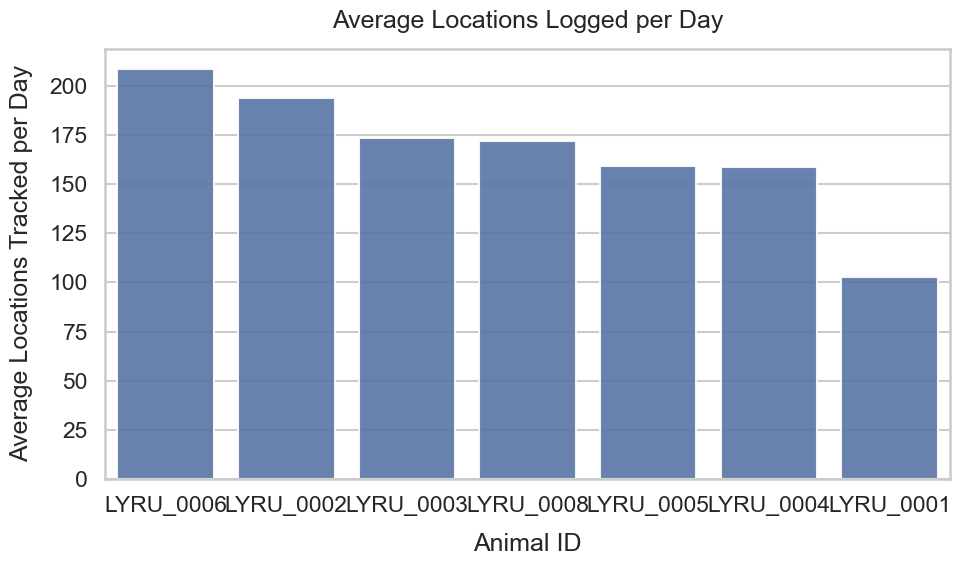

In [23]:
# Let's create a biological profile table for each bobcat
bio_prof = EDA_DF.groupby('animal-id').agg(
    sex=('animal-sex', 'first'),
    mass_grams=('animal-mass', 'first'),
    life_stage=('animal-life-stage', 'first')
)

print("========== BIOLOGICAL PROFILES & DATA DISTRIBUTION ==========")
print(bio_prof)

# Then let's aggregate the data to get a normalized metric of locations per day in order to compare cats with different tracking durations fairly.
profile_summary = EDA_DF.groupby('animal-id').agg(
    total_locations=('location-lat', 'count'),
    first_ping=('timestamp-local', 'min'),
    last_ping=('timestamp-local', 'max')
).reset_index()

# Calculate tracking duration in days for each animal
profile_summary['tracking_duration_days'] = (
    profile_summary['last_ping'] - profile_summary['first_ping']
).dt.total_seconds() / (24 * 3600)

# Normalize: Calculate the average number of locations per day
profile_summary['locs_per_day'] = profile_summary['total_locations'] / profile_summary['tracking_duration_days']

# Sort bars in descending order
profile_summary = profile_summary.sort_values(by='locs_per_day', ascending=False).reset_index(drop=True)

# Display the chart
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=profile_summary,
    x='animal-id',
    y='locs_per_day',
    ax=ax,
    alpha=0.9
)

ax.set_title("Average Locations Logged per Day", pad=15)
ax.set_xlabel("Animal ID", labelpad=12)
ax.set_ylabel("Average Locations Tracked per Day", labelpad=12)
plt.tight_layout()

The biological profile table shows the seven bobcats within the dataset. There are four females and three males. Notice that the males tend to be heavier than the females no matter if the bobcat is in the juvenile or adult life stage.

This graph might look like it displays the general activity of each bobcat but it actually tells more about the hardware reliability of each bobcat's tracking device. 

### **Question #2: How do general activity levels and ground speeds vary among individual bobcats?**

We need to display the `ground-speed` of each bobcat. Since we are dealing with velocity or distance data, we can use box plot to display the results.

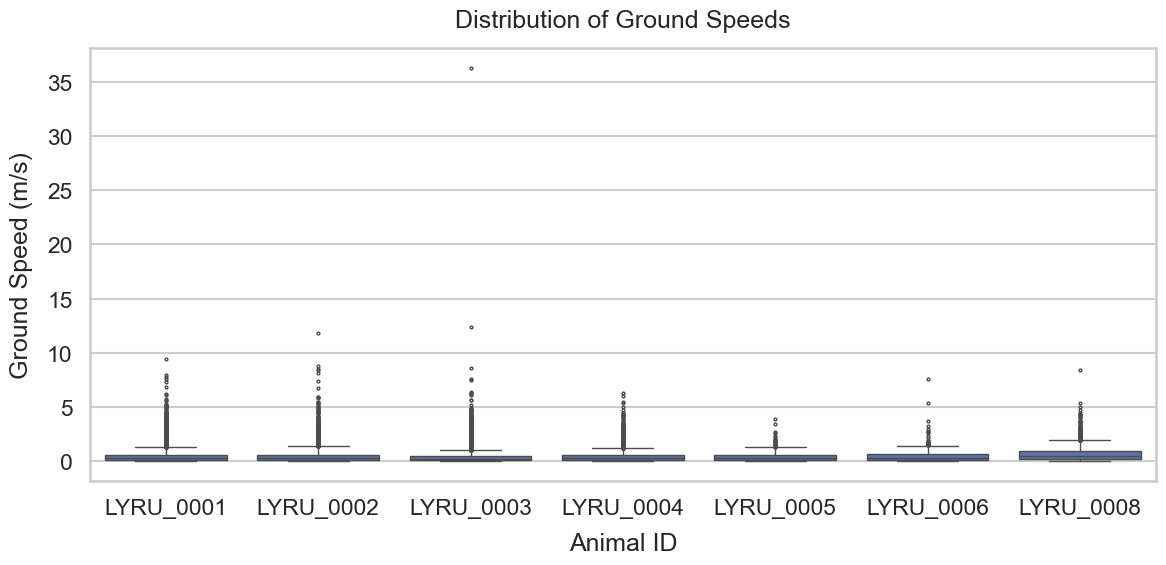

In [24]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(
    data=EDA_DF,
    x='animal-id',
    y='ground-speed',
    ax=ax,
    fliersize=2
)

ax.set_title("Distribution of Ground Speeds", pad=15)
ax.set_xlabel("Animal ID", labelpad=10)
ax.set_ylabel("Ground Speed (m/s)", labelpad=10)

plt.tight_layout()

It seems that the data is heavily skewed. This is most likely because Bobcats tend to spend most of their time resting or grooming leading to data clustered closely to 0 m/s. However, these bobcats also engage in high-speed sprints in occasions that spikes the data.

With these outliers, we could proceed with the boxplot but with logarithmic scaling instead so that we can see the differences between their resting routines and occassional quick sprints.

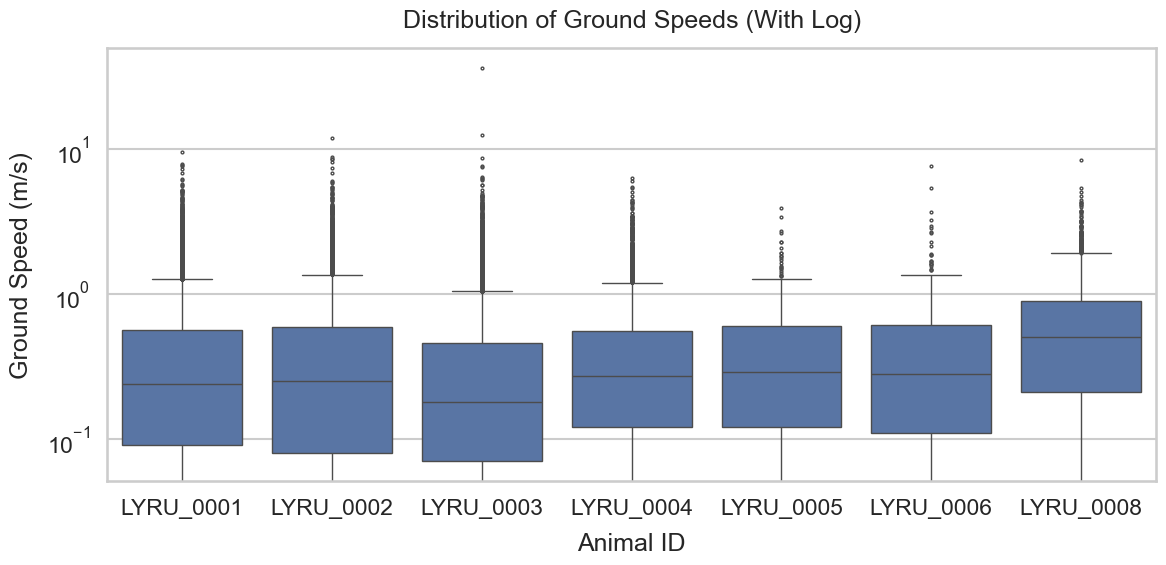

In [25]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(
    data=EDA_DF,
    x='animal-id',
    y='ground-speed',
    ax=ax,
    fliersize=2
)

# This line activates the logarithmic scaling
ax.set_yscale('log')

ax.set_title("Distribution of Ground Speeds (With Log)", pad=15)
ax.set_xlabel("Animal ID", labelpad=10)
ax.set_ylabel("Ground Speed (m/s)", labelpad=10)

plt.tight_layout()

[Insert Explanation]

### **Question 3: Where are the territorial boundaries of these bobcats, and do their home ranges overlap?**



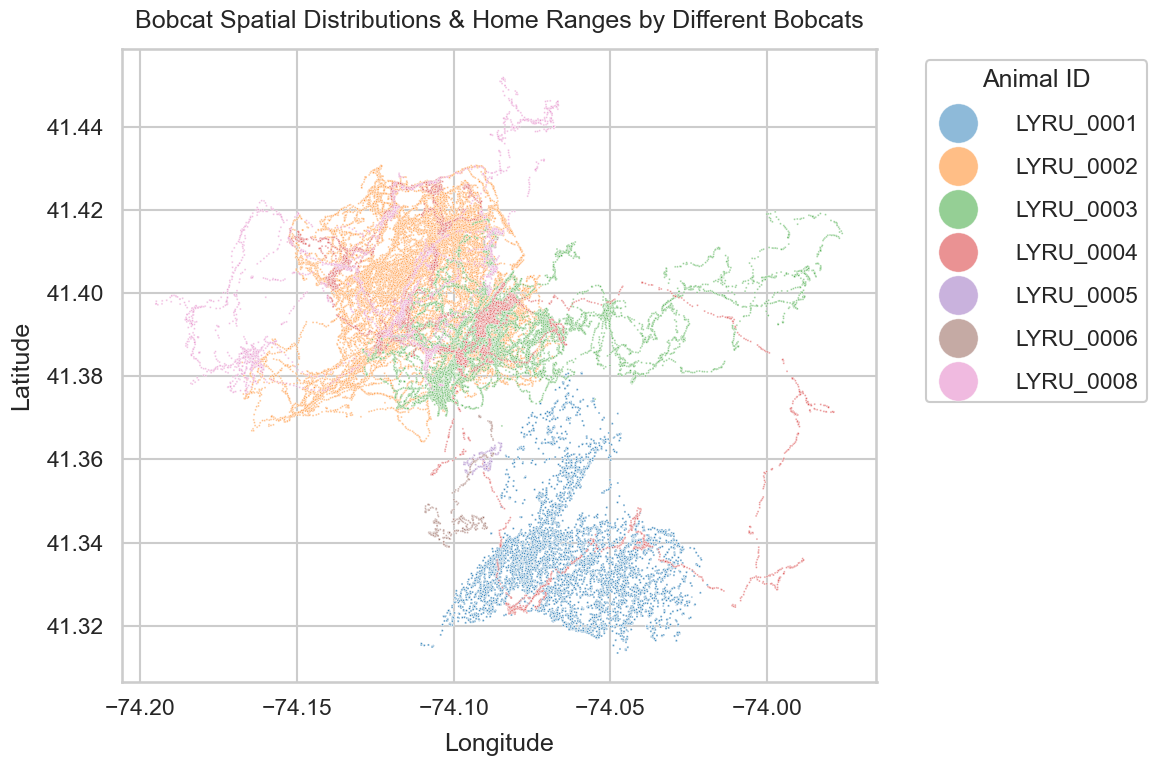

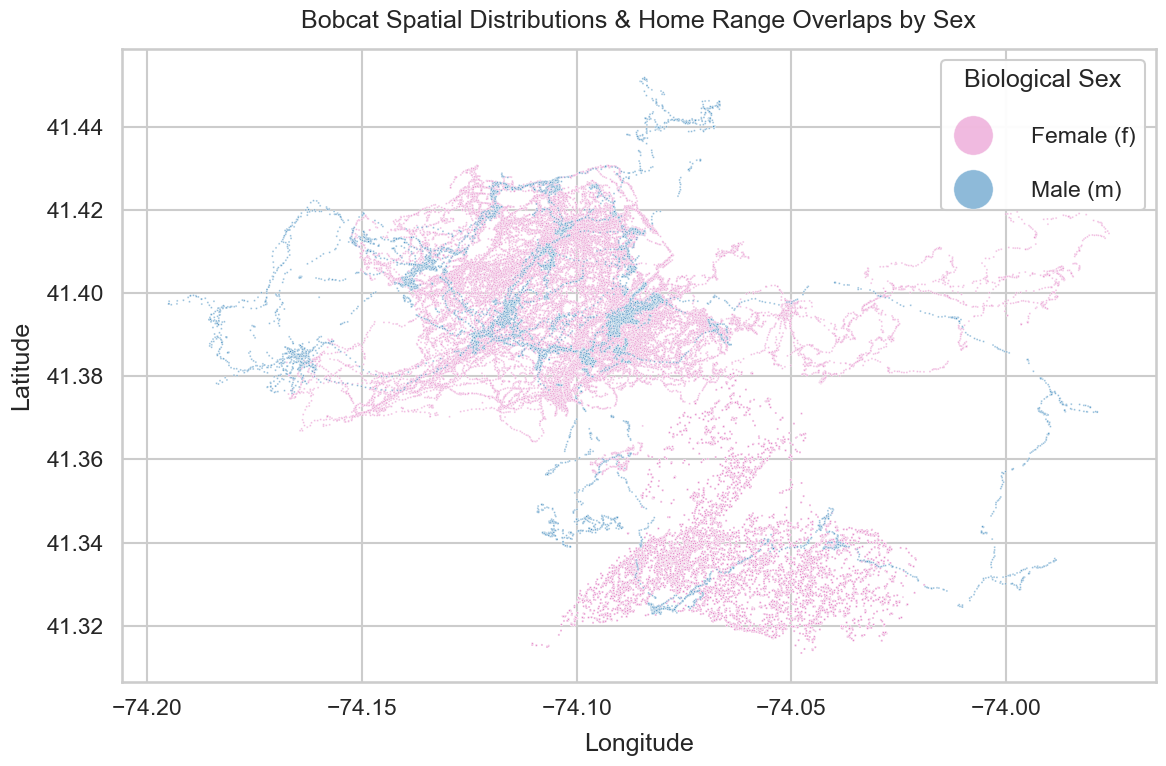

In [35]:
# Plot the locations of each bobcat to visualize spatial distributions and potential home range overlaps 
fig1, ax1 = plt.subplots(figsize=(12, 8))

sns.scatterplot(
    data=EDA_DF,
    x='location-long',
    y='location-lat',
    hue='animal-id',
    alpha=0.5,         # Translucent dots reveal where they spend most of their time (core home ranges)
    s=2,               # Small markers preserve complex trail lines
    palette='tab10',
    linewidth=0.5,
    ax=ax1
)

ax1.set_title("Bobcat Spatial Distributions & Home Ranges by Different Bobcats", pad=15)
ax1.set_xlabel("Longitude", labelpad=10)
ax1.set_ylabel("Latitude", labelpad=10)
ax1.legend(title="Animal ID", bbox_to_anchor=(1.05, 1), loc='upper left', markerscale=20, 
           framealpha=1, labelspacing=1, handletextpad=1.5, frameon=True)

plt.tight_layout()
plt.show()

# Plot the same thing but through sex
fig2, ax2 = plt.subplots(figsize=(12, 8))

sns.scatterplot(
    data=EDA_DF,
    x='location-long',
    y='location-lat',
    hue='animal-sex',
    alpha=0.5,
    s=2,
    palette={'m': '#1f77b4', 'f': '#e377c2'},
    linewidth=0.5,
    ax=ax2
)

ax2.set_title("Bobcat Spatial Distributions & Home Range Overlaps by Sex", pad=15)
ax2.set_xlabel("Longitude", labelpad=10)
ax2.set_ylabel("Latitude", labelpad=10)
handles, labels = ax2.get_legend_handles_labels()
ax2.legend(handles, ['Female (f)', 'Male (m)'], title="Biological Sex", loc='upper right', 
           markerscale=20, framealpha=0.95, labelspacing=1.5, handletextpad=1.5, frameon=True)

plt.tight_layout()
plt.show()

With this scatterplot, we can actually notice a structured system and distinct home range among the bobcats tracked across the Black Rock Forest ecosystem. Instead of a randomized distribution, the high density coordinate clusters dense linear track webs demonstrate that each individual bobcat operates within strict geographic boundaries. 

Furthermore, clear spatial partitioning and intrasexual exclusion are clearly evident where there exist large clouds of same-sex individuals, who avoid sharing core spaces to limit resource competition.

While the adult male (`LYRU_0008`) maintains a home range across higher latitudes, it occassionally overlaps with the female territories situated at lower latitudes. This proves the behavior of bobcats that they only briefly come together for courtship and mating. After the mating, the male and female bobcat tend to seperate, leaving the female bobcat to raise the litter of kittens on her own. This solitary behavior also tracks with the juvenile male bobcat (`LYRU_0004`) who is the only male that briefly stayed within the lower latitude territory where the females tend to stay.

Furthermore, the dataset's sampling skewness is directly captured by the heavy saturation of the orange (`LYRU_0002`), green (`LYRU_0003`), and blue (`LYRU_0001`) clusters, which together comprise nearly 90% of the tracking records. Meanwhile the sparse, faint tracks of peripheral individuals point to extended boundary patrolling and mating movements across the forest boundaries.

### **Question 4: Do all bobcats share the same daily temporal rhythm, or do individuals hunt/rest at different times?**

To answer the question, we first need to calculate the mean of each bobcat's ground speed per hour of the day. Then we can use a lineplot to display the bobcats' temporal rhythm.

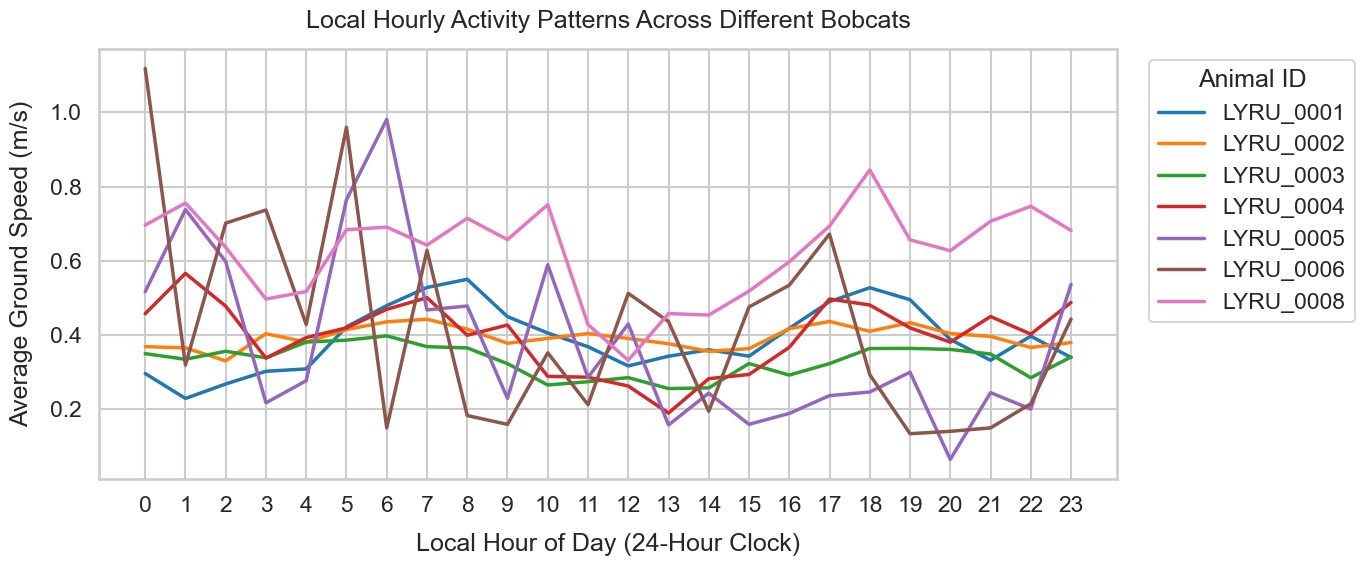

In [29]:
# Calculate mean of ground speed for each hour of the day per individual bobcat 
hourly_trends = EDA_DF.groupby(['animal-id', 'hour-local'])['ground-speed'].mean().reset_index()

# Display the lineplot
fig, ax = plt.subplots(figsize=(14, 6))

sns.lineplot(
    data=hourly_trends,
    x='hour-local',
    y='ground-speed',
    hue='animal-id',
    linewidth=2.5,
    palette='tab10',
    ax=ax
)
ax.set_title("Local Hourly Activity Patterns Across Different Bobcats", pad=15)
ax.set_xlabel("Local Hour of Day (24-Hour Clock)", labelpad=12)
ax.set_ylabel("Average Ground Speed (m/s)", labelpad=12)
ax.set_xticks(range(0, 24))
ax.legend(title="Animal ID", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

The lineplot tells us a distinct crepuscular activity pattern that is synchronized across the entire tracked bobcat population in Black Rock Forest ecosystem. Each individual bobcat demonstrates two coordinated movement during the 24-hour cycle: a significant increase of movement between 04:00 and 08:00 and another burst in the evening between 16:00 and 19:00. These burts of movement hints at their hunting hours.

While the timing of the bobcats' huntings is synchronized, some bobcats stand out significantly in the amplitude (height) of the lines. The adult male (`LYRU_0008`) maintains a consistently higher average ground speed throughout the day, while the juvenile female (`LYRU_0003`) exhibits a much flatter, lower-velocity baseline trajectory.

Furthermore, the dataset's shared rest intervals are captured by the synchronized dropping of the lines, which together bottom out to their lowest activity levels between 11:00 and 14:00 to escape the midday heat and preserve energy.